<a href="https://colab.research.google.com/github/kosar-am/rice-classification-cnn/blob/main/notebooks/04_pytorch_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rice Image Classification using PyTorch


## Import Required Libraries

# Install Kaggle



In [1]:
# Install Kaggle

!pip install -q kagglehub

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import datasets
from torchvision import transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import os
import kagglehub
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from google.colab import drive

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


## Configure Device

In [4]:
# Configure the device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cuda


## Mount Google Drive

In [5]:


drive.mount("/content/drive")

Mounted at /content/drive


## Define Project Paths

In [6]:
# Project paths

PROJECT_PATH = "/content/drive/MyDrive/My-Project/Rice-Classification-2026"

PYTORCH_PATH = f"{PROJECT_PATH}/pytorch"

MODEL_PATH = f"{PYTORCH_PATH}/models/rice_cnn_model2026.pth"

RESULTS_PATH = f"{PYTORCH_PATH}/results"

In [7]:
# Create project directories


os.makedirs(f"{PYTORCH_PATH}/models", exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)

print("Project directories are ready!")

Project directories are ready!


## Install and Configure Kaggle API

In [8]:
# Create Kaggle directory

os.makedirs("/root/.kaggle", exist_ok=True)

## Download the Dataset from Kaggle

In [9]:
# Download the Rice Image Dataset from Kaggle

dataset_path = kagglehub.dataset_download(
    "muratkokludataset/rice-image-dataset"
)

print("Dataset downloaded to:")
print(dataset_path)

100%|██████████| 219M/219M [00:12<00:00, 18.5MB/s]

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/muratkokludataset/rice-image-dataset/versions/1


## Locate the Dataset Directory

In [10]:
# Locate the dataset directory


for root, dirs, files in os.walk(dataset_path):
    print(root)

/root/.cache/kagglehub/datasets/muratkokludataset/rice-image-dataset/versions/1
/root/.cache/kagglehub/datasets/muratkokludataset/rice-image-dataset/versions/1/Rice_Image_Dataset
/root/.cache/kagglehub/datasets/muratkokludataset/rice-image-dataset/versions/1/Rice_Image_Dataset/Karacadag
/root/.cache/kagglehub/datasets/muratkokludataset/rice-image-dataset/versions/1/Rice_Image_Dataset/Ipsala
/root/.cache/kagglehub/datasets/muratkokludataset/rice-image-dataset/versions/1/Rice_Image_Dataset/Basmati
/root/.cache/kagglehub/datasets/muratkokludataset/rice-image-dataset/versions/1/Rice_Image_Dataset/Jasmine
/root/.cache/kagglehub/datasets/muratkokludataset/rice-image-dataset/versions/1/Rice_Image_Dataset/Arborio


## Define Dataset Path

In [11]:
# Dataset path

DATASET_PATH = os.path.join(
    dataset_path,
    "Rice_Image_Dataset"
)

print(DATASET_PATH)

/root/.cache/kagglehub/datasets/muratkokludataset/rice-image-dataset/versions/1/Rice_Image_Dataset


## Define Image Transformations

In [12]:
# Define image transformations

image_transform = transforms.Compose([
    transforms.Resize((250, 250)),
    transforms.ToTensor()
])

In [13]:
print(image_transform)

Compose(
    Resize(size=(250, 250), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


## Load the Dataset

In [14]:
# Load the dataset

dataset = datasets.ImageFolder(
    root=DATASET_PATH,
    transform=image_transform
)

In [15]:
print("Number of images:", len(dataset))

print("Classes:", dataset.classes)

print("Class to index:", dataset.class_to_idx)

Number of images: 75000
Classes: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
Class to index: {'Arborio': 0, 'Basmati': 1, 'Ipsala': 2, 'Jasmine': 3, 'Karacadag': 4}


## Split the Dataset

In [16]:
# Split the dataset into training and validation sets

TRAIN_RATIO = 0.80

train_size = int(TRAIN_RATIO * len(dataset))
validation_size = len(dataset) - train_size

train_dataset, validation_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, validation_size],
    generator=torch.Generator().manual_seed(42)
)

In [17]:
print("Training images:", len(train_dataset))
print("Validation images:", len(validation_dataset))

Training images: 60000
Validation images: 15000


## Create DataLoaders

In [18]:
# Create DataLoaders

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [19]:
print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))

Training batches: 1875
Validation batches: 469


## Explore the Dataset

In [20]:
# Display dataset information

print("Training samples:", len(train_dataset))
print("Validation samples:", len(validation_dataset))

print("\nClasses:")
print(dataset.classes)

Training samples: 60000
Validation samples: 15000

Classes:
['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


In [21]:
# Display one sample image

image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)
print("Class:", dataset.classes[label])

Image shape: torch.Size([3, 250, 250])
Label: 2
Class: Ipsala


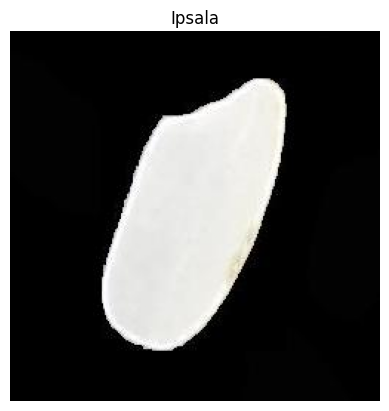

In [22]:
# Show the sample image

plt.imshow(image.permute(1, 2, 0))
plt.title(dataset.classes[label])
plt.axis("off")

plt.show()

## Build the CNN Model

### Build CNN Version 1 (Baseline)

In [23]:
# Build a simple CNN baseline model

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(
            32 * 125 * 125,
            128
        )

        self.fc2 = nn.Linear(
            128,
            5
        )

    def forward(self, x):
        x = self.conv(x)
        x = torch.relu(x)

        x = self.pool(x)

        x = self.flatten(x)

        x = self.fc1(x)
        x = torch.relu(x)

        x = self.fc2(x)

        return x

In [24]:
# Create the model
model = SimpleCNN().to(device)

print(model)

SimpleCNN(
  (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=500000, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=5, bias=True)
)


### Build CNN Version 2


In [25]:
class CNNVersion2(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.pool1 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.pool2 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(
            64 * 62 * 62,
            128
        )

        self.fc2 = nn.Linear(
            128,
            5
        )

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool1(x)

        x = torch.relu(self.conv2(x))
        x = self.pool2(x)

        x = self.flatten(x)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [26]:
model_v2 = CNNVersion2().to(device)

print(model_v2)

CNNVersion2(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=246016, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=5, bias=True)
)


### Build CNN Version 3

In [27]:
class CNNVersion3(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.pool1 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.pool2 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.conv3 = nn.Conv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=3,
            padding=1
        )

        self.pool3 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(
            128 * 31 * 31,
            128
        )

        self.fc2 = nn.Linear(
            128,
            5
        )

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool1(x)

        x = torch.relu(self.conv2(x))
        x = self.pool2(x)

        x = torch.relu(self.conv3(x))
        x = self.pool3(x)

        x = self.flatten(x)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [28]:
model_v3 = CNNVersion3().to(device)

print(model_v3)

CNNVersion3(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=123008, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=5, bias=True)
)


## Build an Optimized CNN

In [29]:
class EfficientCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.pool1 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.pool2 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.conv3 = nn.Conv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=3,
            padding=1
        )

        self.pool3 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.global_pool = nn.AdaptiveAvgPool2d(
            output_size=(1, 1)
        )

        self.fc1 = nn.Linear(
            128,
            128
        )

        self.fc2 = nn.Linear(
            128,
            5
        )

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool1(x)

        x = torch.relu(self.conv2(x))
        x = self.pool2(x)

        x = torch.relu(self.conv3(x))
        x = self.pool3(x)

        x = self.global_pool(x)

        x = torch.flatten(x, start_dim=1)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [30]:
efficient_cnn = EfficientCNN().to(device)

print(efficient_cnn)

EfficientCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=128, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=5, bias=True)
)


## Define Loss Function

In [31]:
criterion = nn.CrossEntropyLoss()

print(criterion)

CrossEntropyLoss()


## Define Optimizer

In [32]:
optimizer = optim.Adam(
    efficient_cnn.parameters(),
    lr=0.001
)

print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## Training Configuration

In [33]:
EPOCHS = 10

train_losses = []
train_accuracies = []

validation_losses = []
validation_accuracies = []

## Train the Model

In [34]:
for epoch in range(EPOCHS):

    efficient_cnn.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = efficient_cnn(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted_labels = torch.max(outputs, dim=1)

        total_samples += labels.size(0)

        correct_predictions += (
            predicted_labels == labels
        ).sum().item()

    epoch_loss = running_loss / len(train_loader)

    epoch_accuracy = (
        100 * correct_predictions / total_samples
    )

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    # Validation
    efficient_cnn.eval()

    validation_running_loss = 0.0
    validation_correct_predictions = 0
    validation_total_samples = 0

    with torch.no_grad():

        for images, labels in validation_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = efficient_cnn(images)

            loss = criterion(outputs, labels)

            validation_running_loss += loss.item()

            _, predicted_labels = torch.max(outputs, dim=1)

            validation_total_samples += labels.size(0)

            validation_correct_predictions += (
                predicted_labels == labels
            ).sum().item()

    validation_epoch_loss = (
        validation_running_loss / len(validation_loader)
    )

    validation_epoch_accuracy = (
        100 * validation_correct_predictions / validation_total_samples
    )

    validation_losses.append(validation_epoch_loss)
    validation_accuracies.append(validation_epoch_accuracy)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Training Loss: {epoch_loss:.4f} | "
        f"Training Accuracy: {epoch_accuracy:.2f}% | "
        f"Validation Loss: {validation_epoch_loss:.4f} | "
        f"Validation Accuracy: {validation_epoch_accuracy:.2f}%"
    )

Epoch 1/10 | Training Loss: 0.5767 | Training Accuracy: 75.48% | Validation Loss: 0.2403 | Validation Accuracy: 91.25%
Epoch 2/10 | Training Loss: 0.2498 | Training Accuracy: 90.59% | Validation Loss: 0.1925 | Validation Accuracy: 92.70%
Epoch 3/10 | Training Loss: 0.2087 | Training Accuracy: 92.08% | Validation Loss: 0.1907 | Validation Accuracy: 92.83%
Epoch 4/10 | Training Loss: 0.1737 | Training Accuracy: 93.64% | Validation Loss: 0.1617 | Validation Accuracy: 93.91%
Epoch 5/10 | Training Loss: 0.1095 | Training Accuracy: 96.01% | Validation Loss: 0.0755 | Validation Accuracy: 97.34%
Epoch 6/10 | Training Loss: 0.0858 | Training Accuracy: 96.96% | Validation Loss: 0.0797 | Validation Accuracy: 97.21%
Epoch 7/10 | Training Loss: 0.0765 | Training Accuracy: 97.20% | Validation Loss: 0.0501 | Validation Accuracy: 98.37%
Epoch 8/10 | Training Loss: 0.0696 | Training Accuracy: 97.44% | Validation Loss: 0.0455 | Validation Accuracy: 98.44%
Epoch 9/10 | Training Loss: 0.0618 | Training Ac

## Save Training Checkpoint

In [35]:
# Save the trained model and training history

CHECKPOINT_PATH = f"{PYTORCH_PATH}/models/rice_cnn_checkpoint2026.pth"

torch.save(
    {
        "model_state_dict": efficient_cnn.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "epochs": EPOCHS,
        "train_losses": train_losses,
        "train_accuracies": train_accuracies,
        "validation_losses": validation_losses,
        "validation_accuracies": validation_accuracies,
        "class_names": dataset.classes
    },
    CHECKPOINT_PATH
)

print("Training checkpoint saved successfully!")
print(CHECKPOINT_PATH)

Training checkpoint saved successfully!
/content/drive/MyDrive/My-Project/Rice-Classification-2026/pytorch/models/rice_cnn_checkpoint2026.pth


## Plot Training Loss

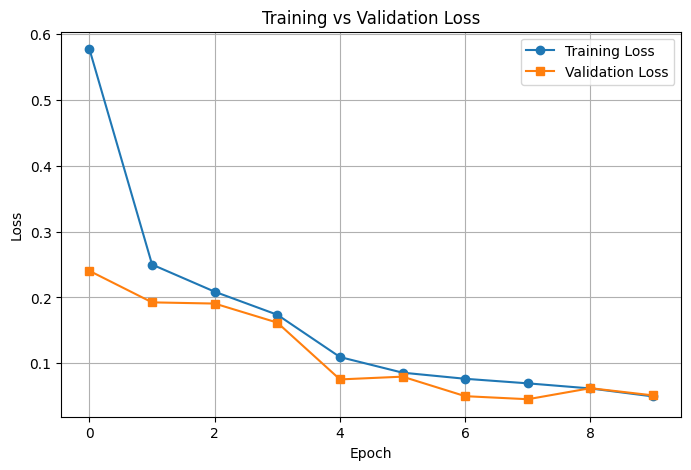

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, marker="o", label="Training Loss")
plt.plot(validation_losses, marker="s", label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.savefig(
    f"{RESULTS_PATH}/training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Plot Training Accuracy

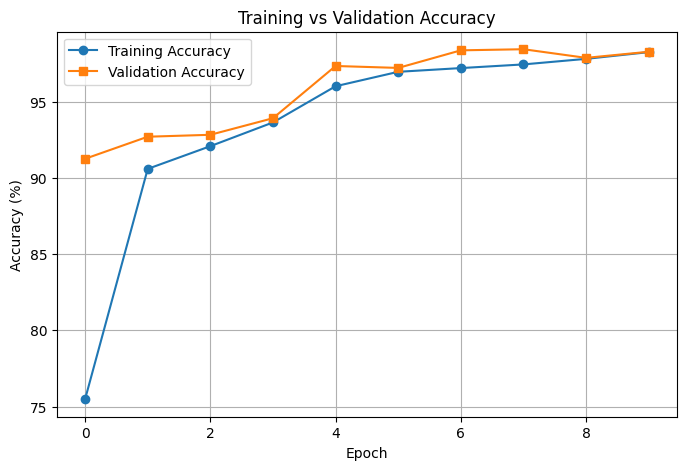

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, marker="o", label="Training Accuracy")
plt.plot(validation_accuracies, marker="s", label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.legend()
plt.grid(True)

plt.savefig(
    f"{RESULTS_PATH}/training_validation_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Generate Predictions

In [40]:
all_predictions = []
all_labels = []

efficient_cnn.eval()

with torch.no_grad():

    for images, labels in validation_loader:

        images = images.to(device)

        outputs = efficient_cnn(images)

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

## Confusion Matrix

<Figure size 800x800 with 0 Axes>

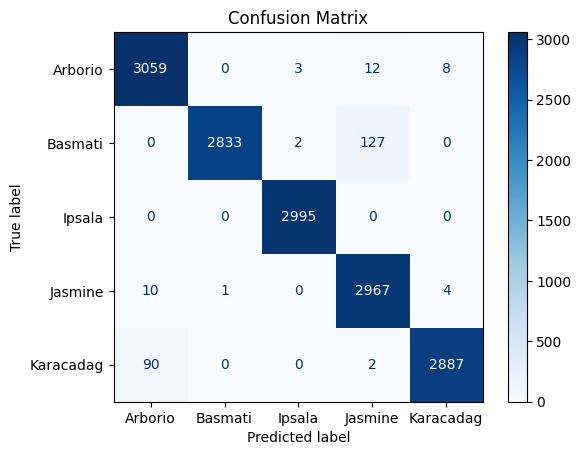

In [41]:


cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(8,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=dataset.classes
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.savefig(
    f"{RESULTS_PATH}/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Classification Report

In [42]:


report = classification_report(
    all_labels,
    all_predictions,
    target_names=dataset.classes
)

print(report)

              precision    recall  f1-score   support

     Arborio       0.97      0.99      0.98      3082
     Basmati       1.00      0.96      0.98      2962
      Ipsala       1.00      1.00      1.00      2995
     Jasmine       0.95      0.99      0.97      2982
   Karacadag       1.00      0.97      0.98      2979

    accuracy                           0.98     15000
   macro avg       0.98      0.98      0.98     15000
weighted avg       0.98      0.98      0.98     15000



In [43]:
with open(
    f"{RESULTS_PATH}/classification_report.txt",
    "w"
) as file:

    file.write(report)

print("Classification report saved successfully!")

Classification report saved successfully!
